# Reaction Energy Profile from CSV

This notebook is the main entry point. The accompanying Python file is imported only as a utility module.

## CSV layout

The first five rows contain figure metadata, path names, and colors. Reaction-state data begin on row 6.

```text
,Figure title
,Reaction coordinate
,Relative energy (kcal/mol)
,Path A,Path B
,#d62728,#1f77b4
R,0.0,0.0
TS1,15.2,16.4
IM1,-8.1,-6.7
```

Blank energy cells are treated as missing values. At the same reaction state, identical displayed energy labels are drawn only once by default.

## Import the plotting module

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from energy_profile_tools_v20260719_r2 import (
    PlotConfig,
    load_profile_csv,
    plot_energy_profile,
)

%matplotlib inline

## User settings

In [6]:
CSV_FILE = Path("trp.csv")
OUTPUT_FILE = Path("trp.svg")

CONFIG = PlotConfig(
    figsize=(10.0, 6.0),
    dpi=600,
    plateau_width=0.82,
    state_spacing=2.0,
    plateau_linewidth=4.0,
    connector_linewidth=2.4,
    connector_linestyle="--",
    zero_line=True,
    show_energy_labels=True,
    deduplicate_energy_labels=True,
    energy_label_decimals=1,
    energy_label_fontsize=20.0,
    energy_label_vertical_offset=8.0,
    energy_label_horizontal_spacing=44.0,
    tick_fontsize=22.0,
    axis_label_fontsize=28.0,
    legend_fontsize=22.0,
    show_title=False,
    show_legend=True,
    connect_across_missing_states=False,
    x_tick_rotation=0.0,
    y_limits=None,
    font_family=None,
)

## Read the CSV

In [7]:
profile = load_profile_csv(CSV_FILE)

print(f"States: {len(profile.state_labels)}")
print(f"Paths: {len(profile.path_labels)}")
print("Path labels:", profile.path_labels)

States: 7
Paths: 1
Path labels: ['Path 1']


## Plot and save the SVG

Saved: trp.svg


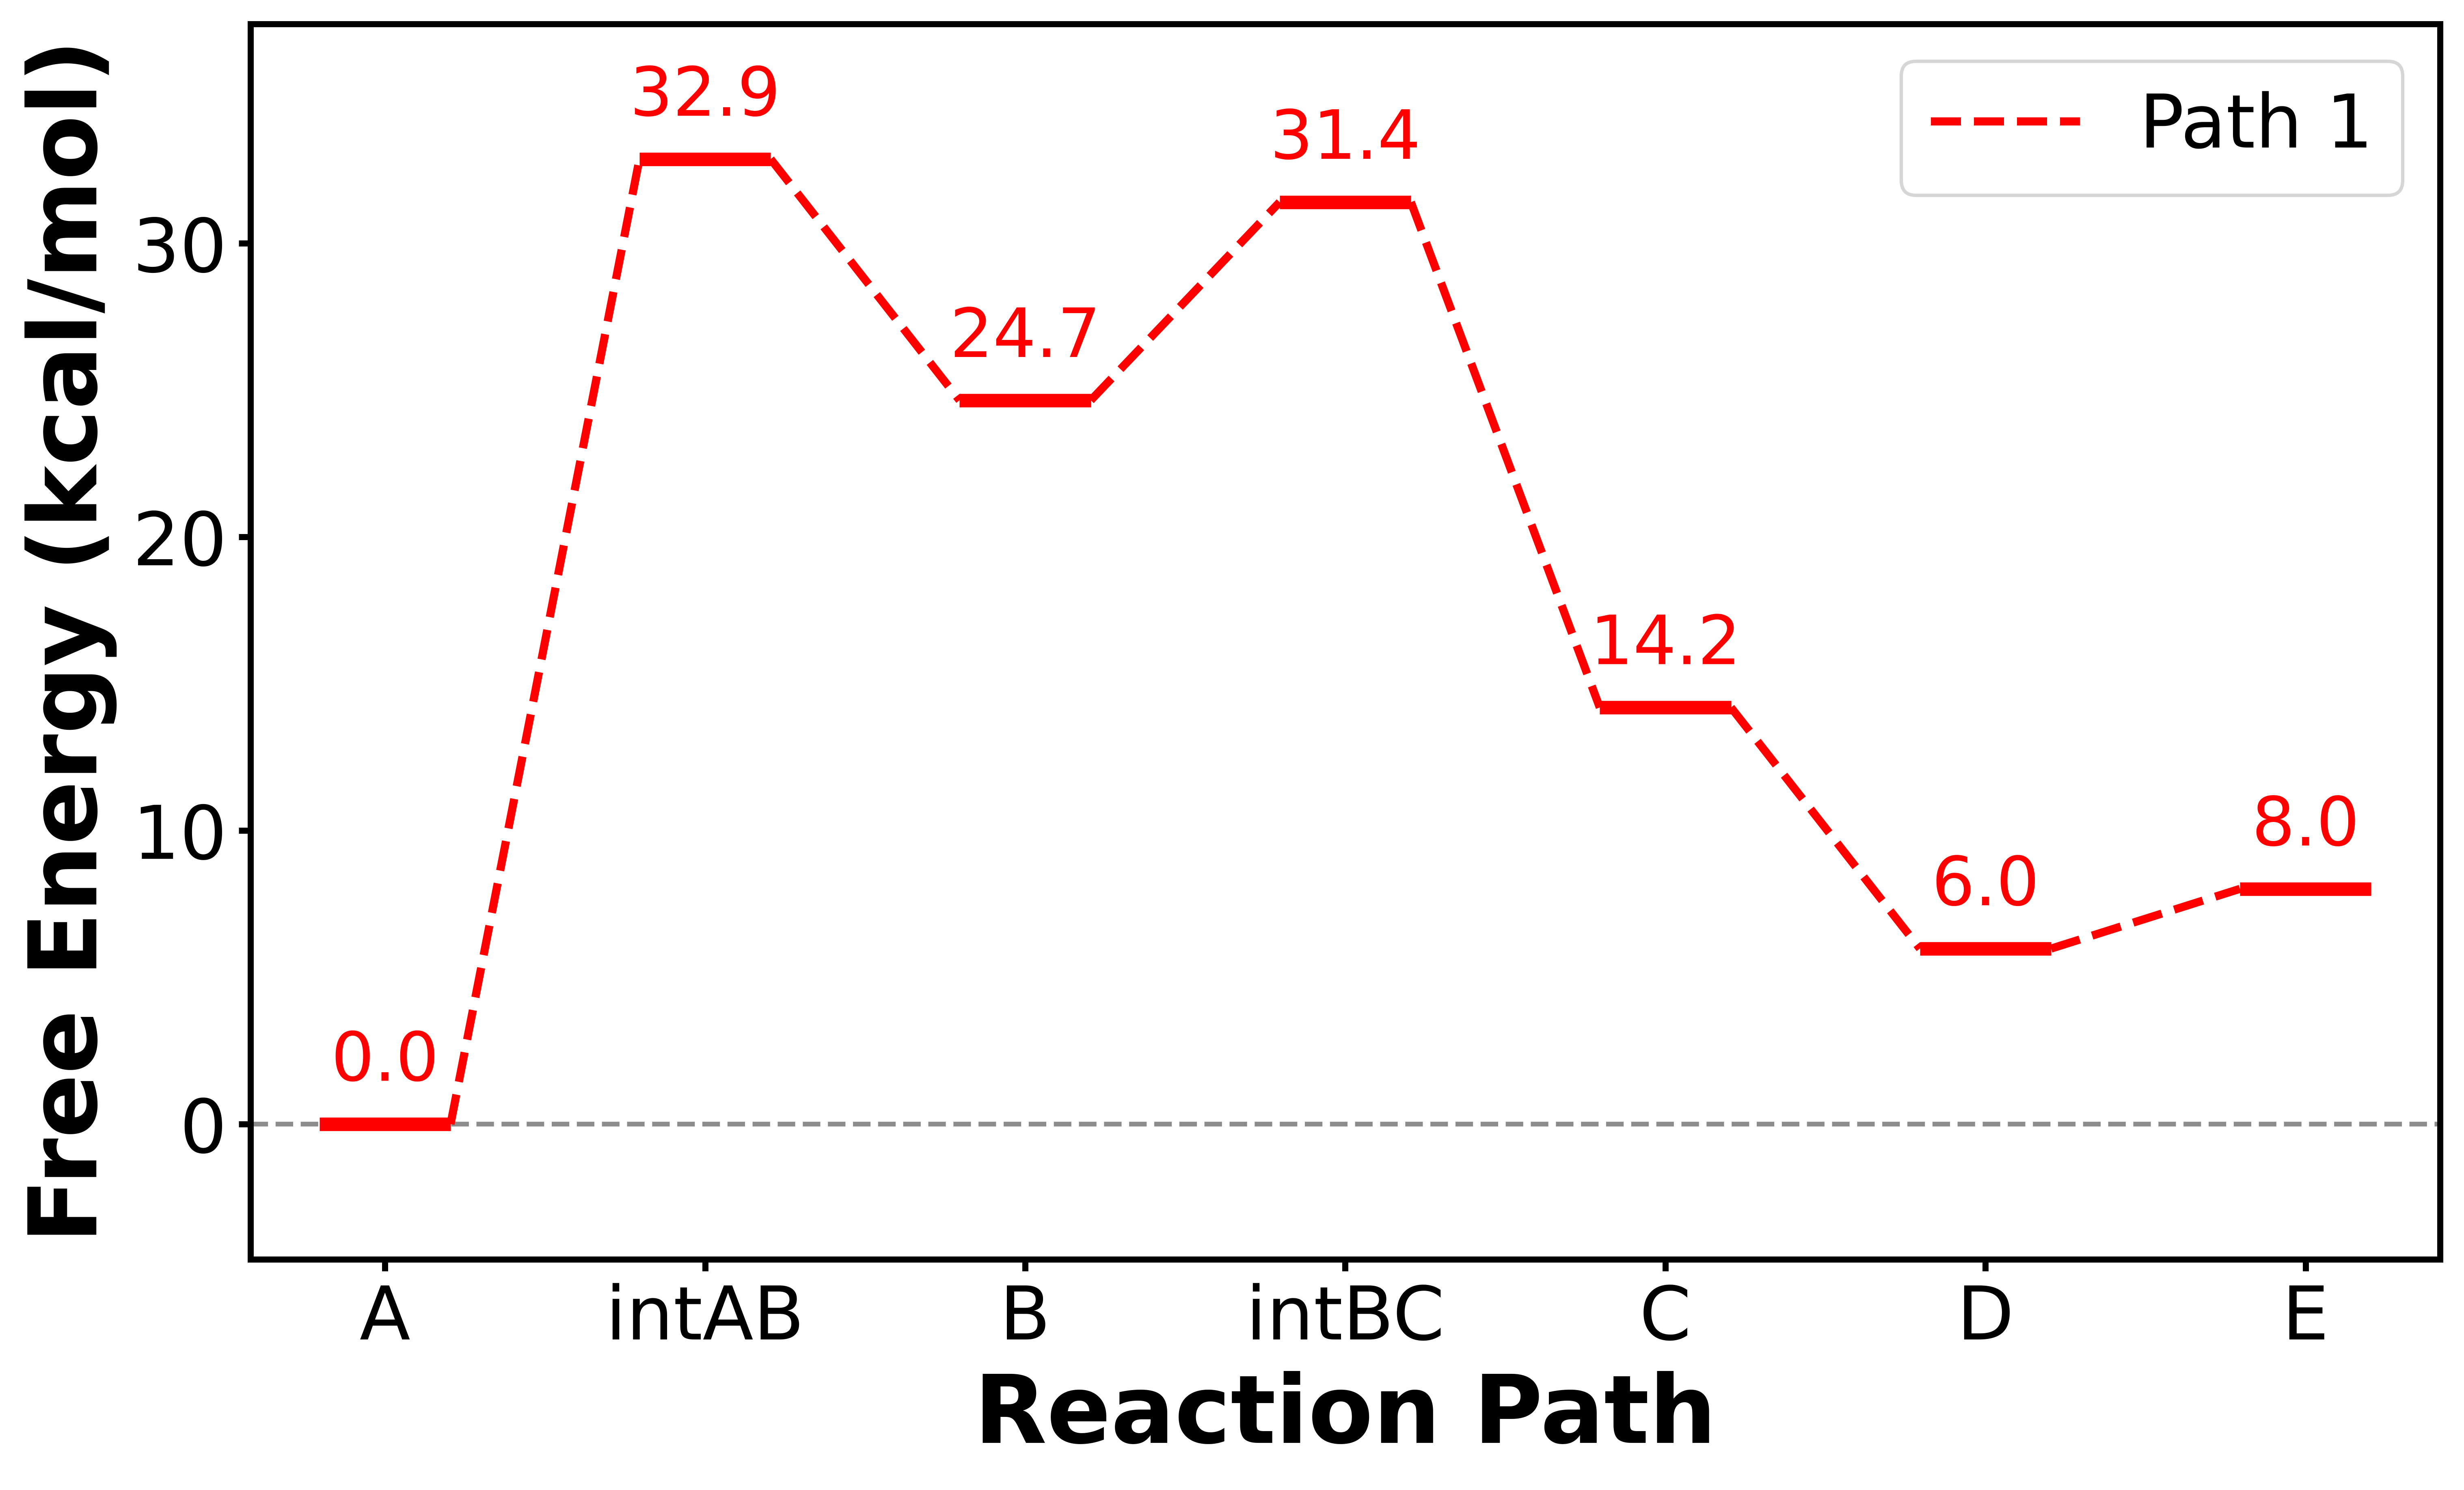

In [8]:
fig, ax = plot_energy_profile(profile, CONFIG)
fig.savefig(OUTPUT_FILE, format="svg", bbox_inches="tight")
print(f"Saved: {OUTPUT_FILE}")
plt.show()